# Stage 2 — Reliable bulk topology

- Gabriel Wendell Celestino Rocha
---

This notebook demonstrates the production Stage-2 API. It does not reimplement FHS or interband-Kubo logic; it orchestrates the tested modules in `src/qhe/topology/`.

## Objectives

1. verify the massive-Dirac local Kubo curvature against its analytic expression;
2. compute FHS and Kubo curvature for the `phi=1/3` Harper-Hofstadter model;
3. compare compatible curvature **densities**, not raw FHS flux against pointwise Kubo data;
4. verify Chern numbers, direct gaps, and mesh refinement.

The frozen sign and gauge choices are documented in `docs/CONVENTIONS.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qhe.models import (
    DiracParameters,
    HarperHofstadterParameters,
    massive_dirac_berry_curvature,
    massive_dirac_hamiltonian,
    massive_dirac_hamiltonian_derivatives,
)
from qhe.topology import (
    analyze_harper_hofstadter_topology,
    harper_hofstadter_convergence,
    interband_kubo_curvature_at_point,
)

def opt_plot():
    plt.grid(True, linestyle = ':', color = '0.50')
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.size'] = 15
    plt.minorticks_on()
    plt.tick_params(axis = 'both', which = 'minor', direction = "in",
                        top = True, right = True, length = 5, width = 1, labelsize = 15)
    plt.tick_params(axis = 'both', which = 'major', direction = "in",
                        top = True, right = True, length = 8, width = 1, labelsize = 15)

## 1. Local massive-Dirac curvature check

In [2]:
dirac = DiracParameters(v_fermi=1.2, mass=0.4)
kx, ky = 0.21, -0.37
energies, eigenvectors = np.linalg.eigh(massive_dirac_hamiltonian(kx, ky, dirac))
d_h_dkx, d_h_dky = massive_dirac_hamiltonian_derivatives(dirac)

omega_kubo = interband_kubo_curvature_at_point(
    energies, eigenvectors, d_h_dkx, d_h_dky
)
omega_analytic = np.asarray(massive_dirac_berry_curvature(kx, ky, dirac))

print("> Kubo curvature:    ", omega_kubo)
print("> Analytic curvature:", omega_analytic)
print("> Maximum error:     ", np.max(np.abs(omega_kubo - omega_analytic)))

> Kubo curvature:     [ 1.05566624 -1.05566624]
> Analytic curvature: [ 1.05566624 -1.05566624]
> Maximum error:      4.440892098500626e-16


## 2. Harper-Hofstadter topology at one mesh resolution

FHS returns a plaquette Berry flux. The plotted FHS quantity below is the flux divided by the plaquette area, and the Kubo quantity is averaged over the same plaquette vertices.

In [3]:
params = HarperHofstadterParameters(p=1, q=3, tx=1.0, ty=1.0)
analysis = analyze_harper_hofstadter_topology(params, nkx=41)

print("> FHS Chern numbers: ", analysis.fhs.chern_numbers)
print("> Kubo Chern numbers:", analysis.kubo.chern_numbers)
print("> Adjacent minimum direct gaps:", analysis.kubo.minimum_direct_gaps)
print("> Minimum FHS link modulus:", analysis.fhs.minimum_link_modulus)
print("> L2 curvature-density errors:", analysis.comparison.l2_error)

> FHS Chern numbers:  [-1.  2. -1.]
> Kubo Chern numbers: [-0.99999996  2.         -1.00000004]
> Adjacent minimum direct gaps: [1.26794919 1.27257008]
> Minimum FHS link modulus: 0.9829072380349312
> L2 curvature-density errors: [0.01915857 0.02694085 0.01913947]


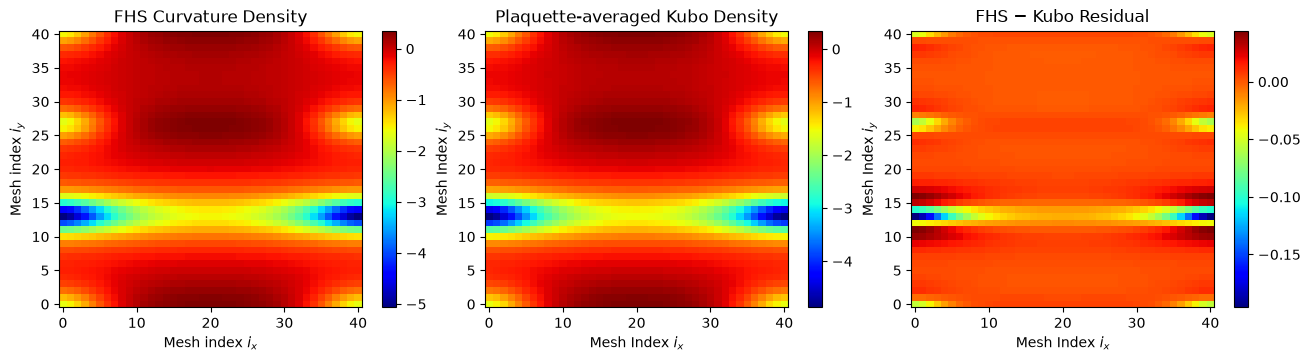

In [4]:
band = 0
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)

image = axes[0].imshow(analysis.fhs.curvature_density[:, :, band].T, cmap="jet", origin="lower", aspect="auto")
axes[0].set_title("FHS Curvature Density")
axes[0].set_xlabel("Mesh index $i_x$")
axes[0].set_ylabel("Mesh index $i_y$")
fig.colorbar(image, ax=axes[0])

image = axes[1].imshow(analysis.comparison.kubo_plaquette_average[:, :, band].T, cmap="jet", origin="lower", aspect="auto")
axes[1].set_title("Plaquette-averaged Kubo Density")
axes[1].set_xlabel("Mesh Index $i_x$")
axes[1].set_ylabel("Mesh Index $i_y$")
fig.colorbar(image, ax=axes[1])

image = axes[2].imshow(analysis.comparison.residual[:, :, band].T, cmap="jet", origin="lower", aspect="auto")
axes[2].set_title("FHS $-$ Kubo Residual")
axes[2].set_xlabel("Mesh Index $i_x$")
axes[2].set_ylabel("Mesh Index $i_y$")
fig.colorbar(image, ax=axes[2]);

## 3. Mesh-refinement study

In [5]:
convergence = harper_hofstadter_convergence(params, mesh_sizes=(21, 41, 81))

for index, resolution in enumerate(convergence.mesh_sizes):
    print(
        f"> N={resolution:3d} | FHS={convergence.fhs_chern_numbers[index]} | "
        f"Kubo={convergence.kubo_chern_numbers[index]} | "
        f"L2={convergence.l2_errors[index]}"
    )

> N= 21 | FHS=[-1.  2. -1.] | Kubo=[-1.00065318  2.00000027 -0.99934709] | L2=[0.0568566  0.09464193 0.07633818]
> N= 41 | FHS=[-1.  2. -1.] | Kubo=[-0.99999996  2.         -1.00000004] | L2=[0.01915857 0.02694085 0.01913947]
> N= 81 | FHS=[-1.  2. -1.] | Kubo=[-1.  2. -1.] | L2=[0.00501936 0.00706275 0.00501936]


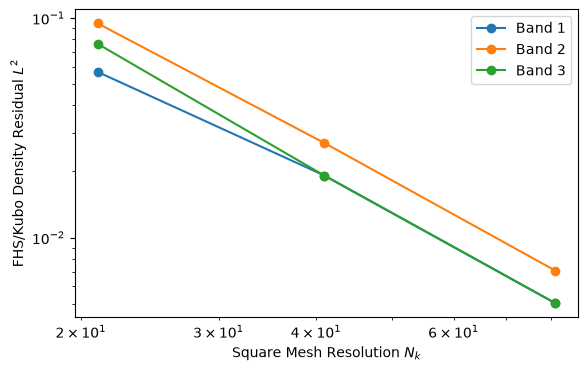

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
for band in range(3):
    ax.loglog(convergence.mesh_sizes, convergence.l2_errors[:, band], marker="o", label=f"Band {band + 1}")
ax.set_xlabel("Square Mesh Resolution $N_k$")
ax.set_ylabel("FHS/Kubo Density Residual $L^2$")
ax.legend();

## Stage-2 acceptance statement

For the frozen `phi=1/3` conventions, the target sequence is `(-1, 2, -1)`. The FHS result is exactly quantized at the tested resolutions. The Kubo integral and the compatible density residuals converge under mesh refinement. This establishes the periodic bulk-topology layer required before any ribbon or real-space dynamics claim is introduced.

---